In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import gridspec
from sklearn.decomposition import PCA

from ae import AE

Loading model.

In [2]:
ae2 =  AE(device='cpu', latent_dim=2)
ae3 =  AE(device='cpu', latent_dim=3)
ae5 =  AE(device='cpu', latent_dim=5)
ae10 =  AE(device='cpu', latent_dim=10)

In [3]:
model2 = torch.load('best_models/autoencoder_ld2_ausio2.pth', map_location=torch.device('cpu'), weights_only=True)
model3 = torch.load('best_models/autoencoder_ld3_ausio2.pth', map_location=torch.device('cpu'), weights_only=True)
model5 = torch.load('best_models/autoencoder_ld5_ausio2.pth', map_location=torch.device('cpu'), weights_only=True)
model10 = torch.load('best_models/autoencoder_ld10_ausio2.pth', map_location=torch.device('cpu'), weights_only=True)

ae2.load_state_dict(model2)
ae3.load_state_dict(model3)
ae5.load_state_dict(model5)
ae10.load_state_dict(model10)

<All keys matched successfully>

## Learning Curves

Plotting learning curves.

In [4]:
loss2 = np.load('best_models/loss_autoencoder_ld2_ausio2.npy')
loss3 = np.load('best_models/loss_autoencoder_ld3_ausio2.npy')
loss5 = np.load('best_models/loss_autoencoder_ld5_ausio2.npy')
loss10 = np.load('best_models/loss_autoencoder_ld10_ausio2.npy')

epochs2 = [i for i in range(loss2.shape[0])]
epochs3 = [i for i in range(loss3.shape[0])]
epochs5 = [i for i in range(loss5.shape[0])]
epochs10 = [i for i in range(loss10.shape[0])]

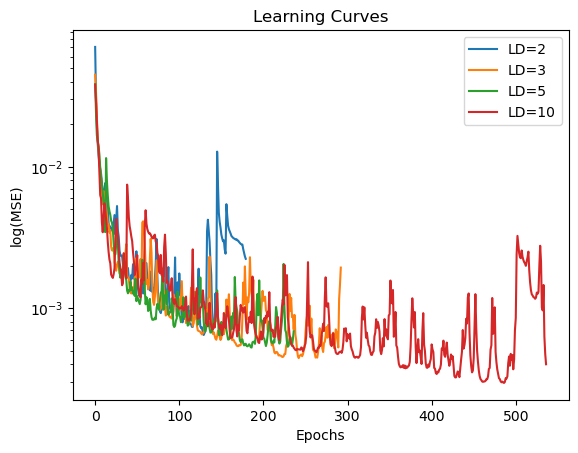

In [5]:
plt.plot(epochs2, loss2, label='LD=2')
plt.plot(epochs3, loss3, label='LD=3')
plt.plot(epochs5, loss5, label='LD=5')
plt.plot(epochs10, loss10, label='LD=10')

plt.yscale('log')
plt.ylabel('log(MSE)')
plt.xlabel('Epochs')
plt.title('Learning Curves')
plt.legend()
plt.show()

## Model avaliation

Loading data.

In [6]:
data = np.load('dataset_TipAu_SiO2_annotated.npz')['curves']
labels = np.load('dataset_TipAu_SiO2_annotated.npz')['labels']

data = torch.tensor(data, dtype=torch.float32).unsqueeze(1)
data /= data.max()

Testing.

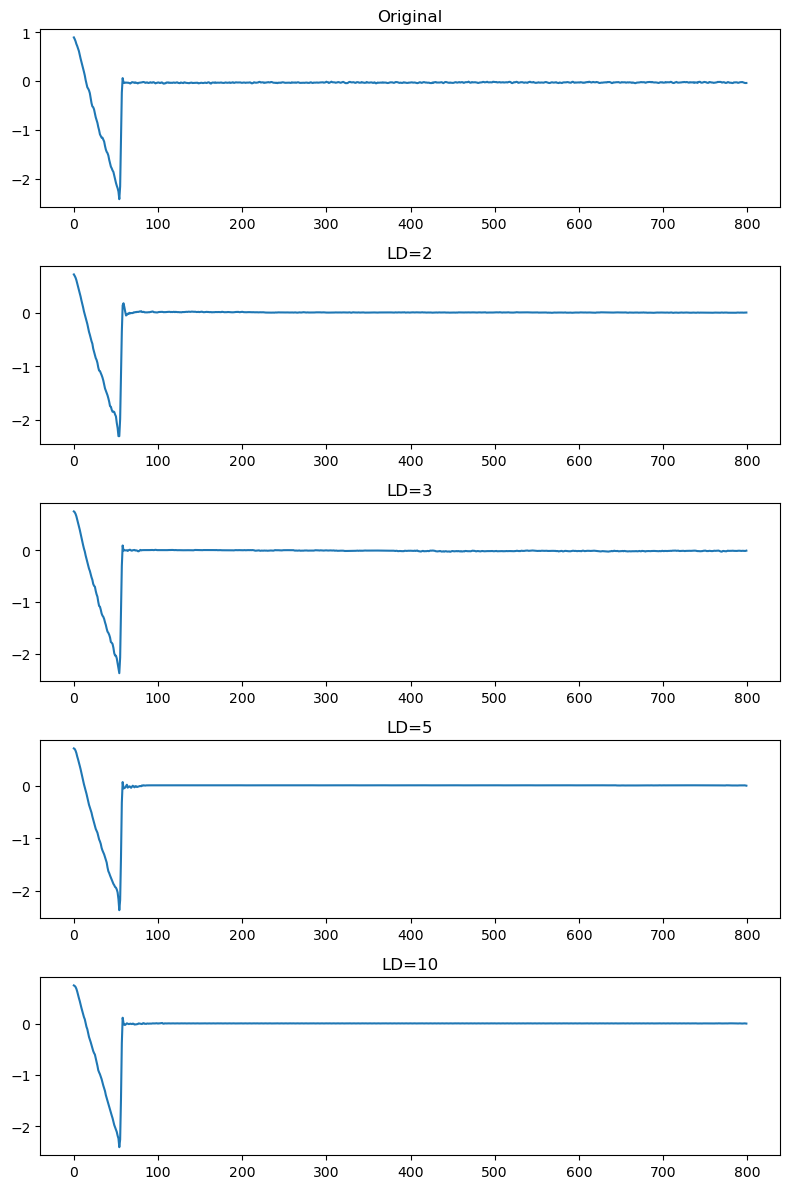

In [7]:
curve0 = data[0]

with torch.no_grad():
    curve0_pred2 = ae2(curve0.unsqueeze(0))
    curve0_pred3 = ae3(curve0.unsqueeze(0))
    curve0_pred5 = ae5(curve0.unsqueeze(0))
    curve0_pred10 = ae10(curve0.unsqueeze(0))

fig, ax = plt.subplots(5, 1, figsize=(8, 12))

im0 = ax[0].plot(curve0.squeeze())
ax[0].set_title('Original')

im1 = ax[1].plot(curve0_pred2.squeeze())
ax[1].set_title('LD=2')

im1 = ax[2].plot(curve0_pred3.squeeze())
ax[2].set_title('LD=3')

im1 = ax[3].plot(curve0_pred5.squeeze())
ax[3].set_title('LD=5')

im1 = ax[4].plot(curve0_pred10.squeeze())
ax[4].set_title('LD=10')

plt.tight_layout()
plt.show()

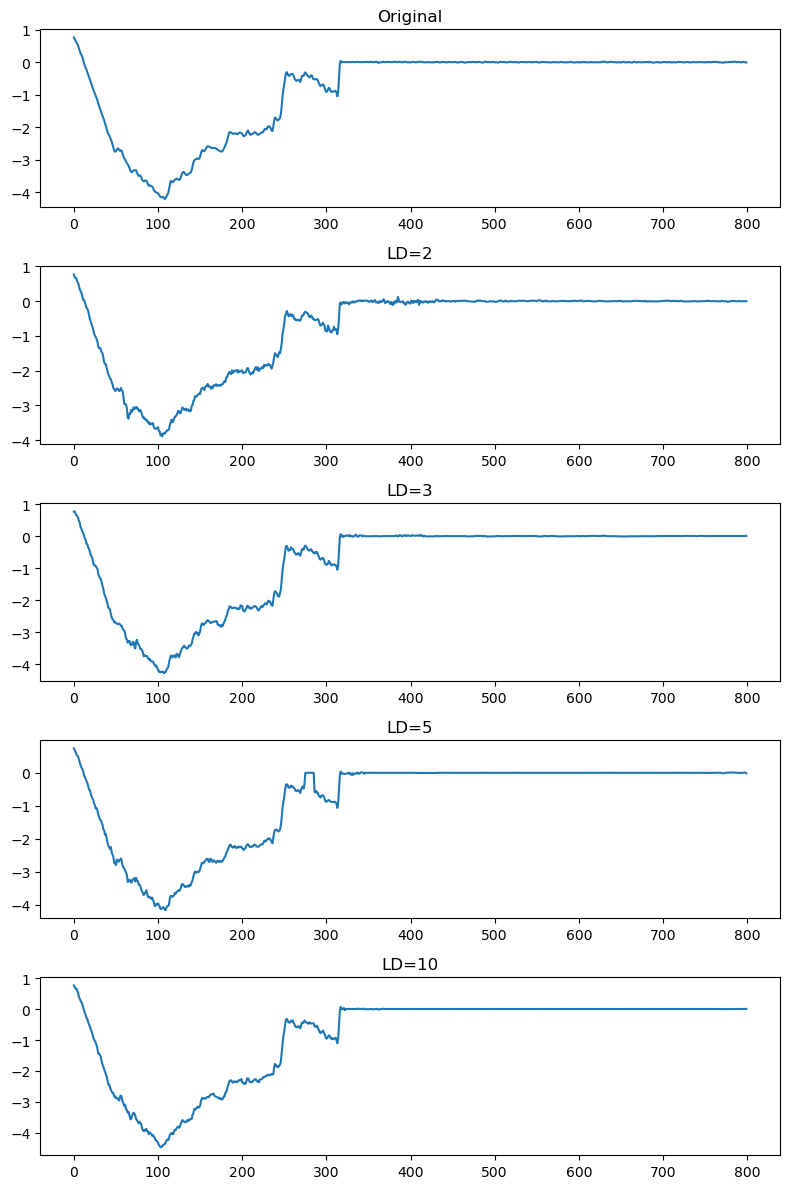

In [8]:
curve15 = data[15]

with torch.no_grad():
    curve15_pred2 = ae2(curve15.unsqueeze(0))
    curve15_pred3 = ae3(curve15.unsqueeze(0))
    curve15_pred5 = ae5(curve15.unsqueeze(0))
    curve15_pred10 = ae10(curve15.unsqueeze(0))

fig, ax = plt.subplots(5, 1, figsize=(8, 12))

im0 = ax[0].plot(curve15.squeeze())
ax[0].set_title('Original')

im1 = ax[1].plot(curve15_pred2.squeeze())
ax[1].set_title('LD=2')

im1 = ax[2].plot(curve15_pred3.squeeze())
ax[2].set_title('LD=3')

im1 = ax[3].plot(curve15_pred5.squeeze())
ax[3].set_title('LD=5')

im1 = ax[4].plot(curve15_pred10.squeeze())
ax[4].set_title('LD=10')

plt.tight_layout()
plt.show()

## Latent Space

Plotting for LD=2.

In [9]:
ld2_ausio2 = np.load('best_models/ld2_ausio2_ausio2.npy')
mask_0 = (labels == 0) 
mask_1 = (labels == 1) 

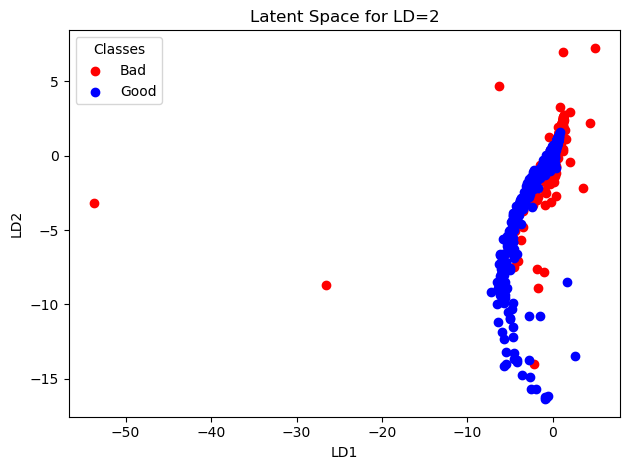

In [10]:
plt.scatter(ld2_ausio2[mask_0, 0], ld2_ausio2[mask_0, 1], c='red', label='Bad')
plt.scatter(ld2_ausio2[mask_1, 0], ld2_ausio2[mask_1, 1], c='blue', label='Good')

plt.legend(title="Classes")
plt.xlabel('LD1')
plt.ylabel('LD2')
plt.title('Latent Space for LD=2')
plt.tight_layout()
plt.show()

For the other LDs, with PCA.

In [11]:
ld3_ausio2 = np.load('best_models/ld3_ausio2_ausio2.npy')

pca = PCA(n_components=2)

ld3_ausio2_pca = pca.fit_transform(ld3_ausio2)

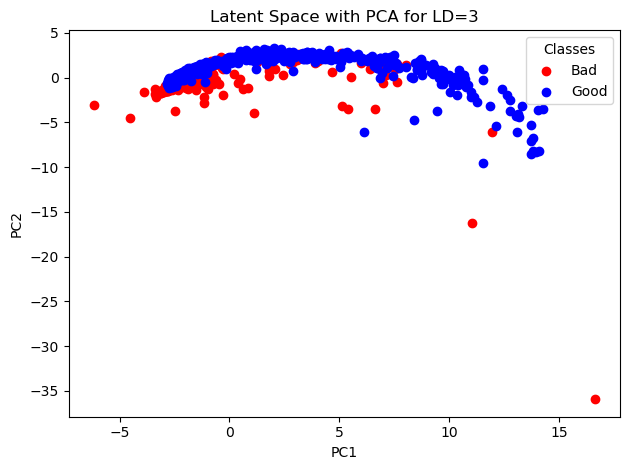

In [12]:
plt.scatter(ld3_ausio2_pca[mask_0, 0], ld3_ausio2_pca[mask_0, 1], c='red', label='Bad')
plt.scatter(ld3_ausio2_pca[mask_1, 0], ld3_ausio2_pca[mask_1, 1], c='blue', label='Good')

plt.legend(title="Classes")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Latent Space with PCA for LD=3')
plt.tight_layout()
plt.show()

In [13]:
ld5_ausio2 = np.load('best_models/ld5_ausio2_ausio2.npy')

pca = PCA(n_components=2)

ld5_ausio2_pca = pca.fit_transform(ld5_ausio2)

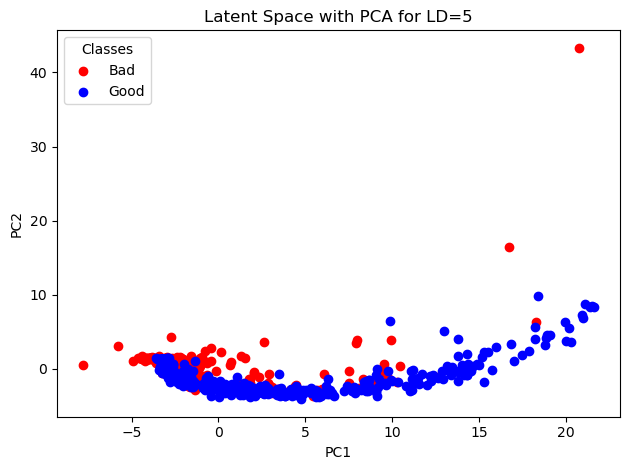

In [14]:
plt.scatter(ld5_ausio2_pca[mask_0, 0], ld5_ausio2_pca[mask_0, 1], c='red', label='Bad')
plt.scatter(ld5_ausio2_pca[mask_1, 0], ld5_ausio2_pca[mask_1, 1], c='blue', label='Good')

plt.legend(title="Classes")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Latent Space with PCA for LD=5')
plt.tight_layout()
plt.show()

In [15]:
ld10_ausio2 = np.load('best_models/ld10_ausio2_ausio2.npy')

pca = PCA(n_components=2)

ld10_ausio2_pca = pca.fit_transform(ld10_ausio2)

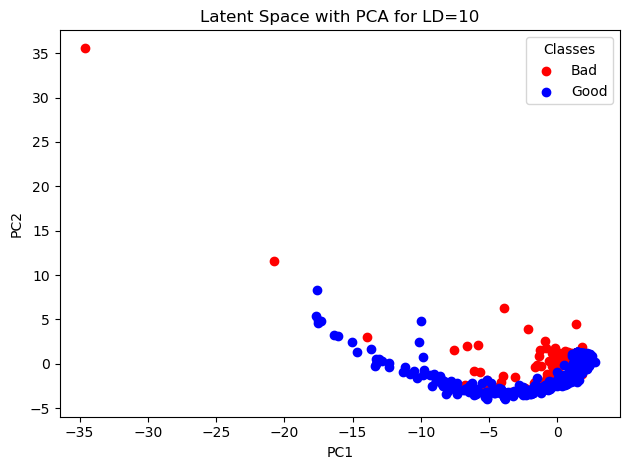

In [16]:
plt.scatter(ld10_ausio2_pca[mask_0, 0], ld10_ausio2_pca[mask_0, 1], c='red', label='Bad')
plt.scatter(ld10_ausio2_pca[mask_1, 0], ld10_ausio2_pca[mask_1, 1], c='blue', label='Good')

plt.legend(title="Classes")
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Latent Space with PCA for LD=10')
plt.tight_layout()
plt.show()